In [62]:
from pathlib import Path
import pydicom
import math
import numpy as np
import matplotlib.pyplot as plt

## Read a single .dcm file, print the patient name, modality, rows, and columns. Display the image in grayscale.

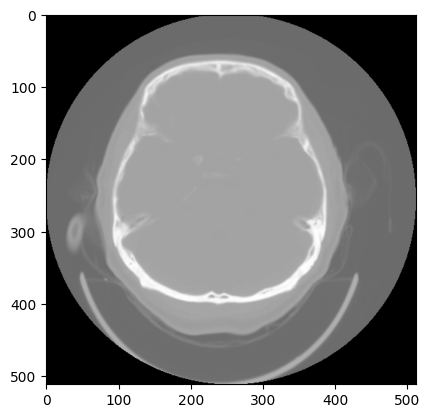

In [9]:
ds = pydicom.dcmread('ID_000854890.dcm')
c1 = ds.pixel_array
plt.imshow(c1,cmap='gray');

In [22]:
print(f"Scan Modality: ", ds.Modality)
print(f"No of Rows:", ds.Rows)
print(f"No of Columns:", ds.Columns)

Scan Modality:  CT
No of Rows: 512
No of Columns: 512


## Read a folder of DICOM slices, sort them by InstanceNumber, and stack into a 3D NumPy array. Print the final shape.

In [65]:
path = Path('Brain/')

all_files = list(path.glob("*"))

brain_data = []

for path in all_files:
    brain_data.append(pydicom.dcmread(path))

brain_data_ordered = sorted( brain_data, key=lambda s: s.PatientID)

volume = np.stack([s.pixel_array for s in brain_data_ordered])

print("3D Volume shape:", volume.shape)

3D Volume shape: (5, 512, 512)


## From a 3D volume, display slices 0, 25, 50, 75, and 99 side by side in one matplotlib figure with proper titles.

In [66]:
path = Path('Brain/')

In [67]:
all_files = list(path.glob("*"))

In [68]:
brain_data = []

for path in all_files:
    brain_data.append(pydicom.dcmread(path))

In [71]:
brain_data_ordered = sorted( brain_data, key=lambda s: s.PatientID)

volume = np.stack([s.pixel_array for s in brain_data_ordered])

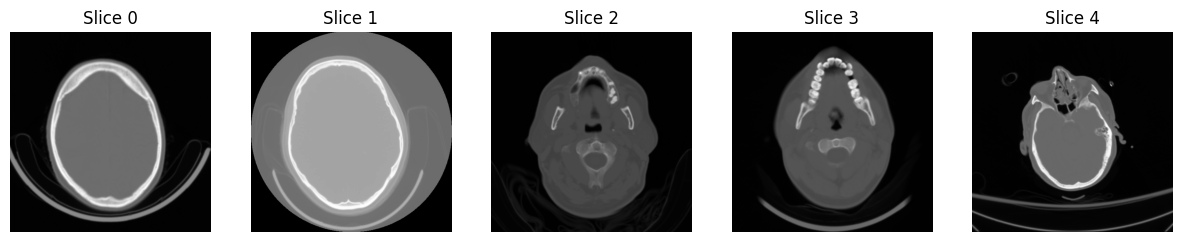

In [86]:
indices = [0, 1, 2, 3, 4]
labels = ['Slice 0', 'Slice 1', 'Slice 2', 'Slice 3', 'Slice 4']

fig, axis = plt.subplots(1, 5, figsize=(15, 4))

for i in range(5):
    axis[i].imshow(volume[indices[i]], cmap='gray')
    axis[i].set_title(labels[i])
    axis[i].axis('off')

plt.show()

## Read a .dcm file and apply a window/level adjustment manually: windowed = np.clip(image, center-width/2, center+width/2) with a CT lung window (center=−600, width=1500). Compare before and after.

In [74]:
ds = pydicom.dcmread('ID_00355bf48.dcm')
c2 = ds.pixel_array

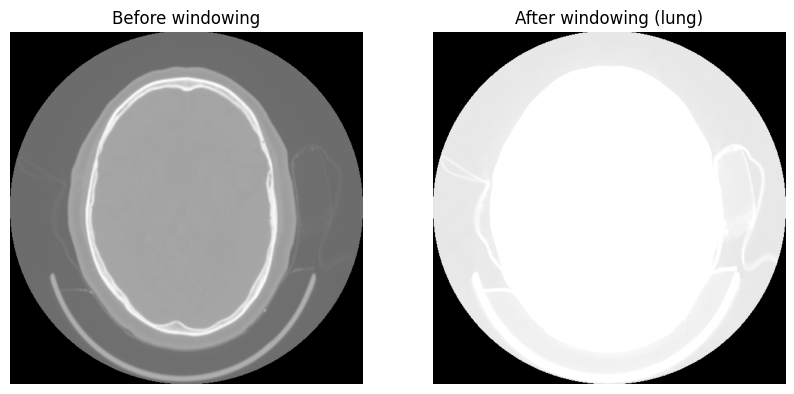

In [87]:
center = -600
width = 1500


windowed = np.clip(c2, center - width/2, center + width/2)


fig, axis = plt.subplots(1, 2, figsize=(10, 5))

axis[0].imshow(c2, cmap='gray')
axis[0].set_title('Before windowing')
axis[0].axis('off')

axis[1].imshow(windowed, cmap='gray')
axis[1].set_title('After windowing (lung)')
axis[1].axis('off')

plt.show()

## Loop through all .dcm files in a folder and print a table of PatientID, StudyDate, Modality, and image dimensions for each file.

In [79]:
path = Path('Brain/')

all_files = list(path.glob("*"))

brain_data = []

for path in all_files:
    brain_data.append(pydicom.dcmread(path))


In [83]:
print(f"{'PatientID':<15} {'Modality':<10} {'Rows':<6} {'Cols':<6}")
print("-" * 40)

for ds in brain_data:
    print(f"{str(ds.PatientID):<15} {str(ds.Modality):<10} {ds.Rows:<6} {ds.Columns:<6}")

PatientID       Modality   Rows   Cols  
----------------------------------------
ID_62a14a88     CT         512    512   
ID_598f3b9e     CT         512    512   
ID_7b5daa6f     CT         512    512   
ID_21952137     CT         512    512   
ID_a60afbdd     CT         512    512   
